In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import ImageFile 
ImageFile.LOAD_TRUNCATED_IMAGES = True


I0000 00:00:1779737167.757339    6385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779737167.758057    6385 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779737167.814004    6385 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779737169.601992    6385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
work_dir = os.getcwd()
work_dir

'/workspaces/XrayFractureClass/jupytr_notebooks'

In [3]:
my_data_dir = '/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'
train_path = my_data_dir + '/train'
val_path = my_data_dir + '/val'
test_path = my_data_dir + '/test'
print (train_path)
print(os.path.exists(train_path))

/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train
True


In [4]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(work_dir) and version in os.listdir(work_dir + '/outputs'):
    print('Old version is already available create a new version.')
    pass
else:
    os.makedirs(name=file_path)

Old version is already available create a new version.


In [5]:
labels = os.listdir(train_path)
print(f"Project Labels: {labels}")

Project Labels: ['fractured', 'not fractured']


In [6]:
import joblib
version = 'v1'
file_path = f'/workspaces/XrayFractureClass/outputs/{version}'
os.makedirs (file_path, exist_ok=True )

image_shape = (224, 224, 3)

joblib.dump(value=image_shape, filename=f'{file_path}/image_shape.pkl')
image_shape = joblib.load(filename=f'{file_path}/image_shape.pkl')
print (f'image_shape : {image_shape}')

image_shape : (224, 224, 3)


* train - fractured: 4606 images
* train - not fractured: 4640 images
* val - fractured: 337 images
* val - not fractured: 492 images
* test - fractured: 238 images
* test - not fractured: 268 images




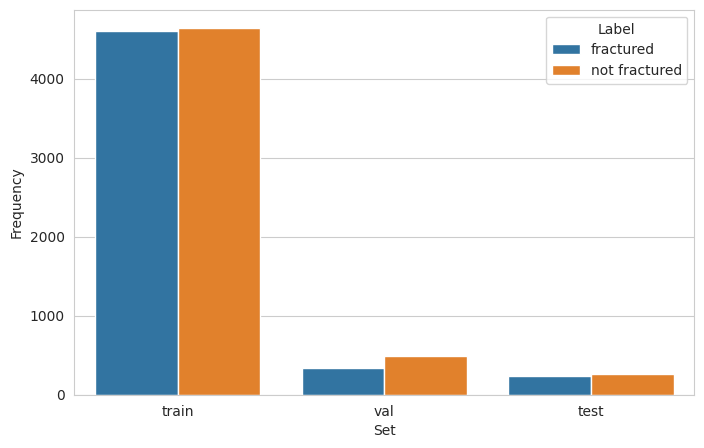

In [7]:
labels = ['fractured', 'not fractured']
file_path = '/workspaces/XrayFractureClass/outputs'
df_freq = pd.DataFrame([])

for folder in ['train', 'val', 'test']:
    for label in labels:
        freq = int(len(os.listdir(my_data_dir + '/' + folder + '/' + label)))
        
        df_freq = pd.concat([df_freq, pd.DataFrame([{'Set': folder, 'Label': label, 'Frequency': freq}])  
        ], ignore_index = True)

        print(
            f"* {folder} - {label}: {len(os.listdir(my_data_dir+'/'+ folder + '/' + label))} images")

print("\n")
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.savefig(f'{file_path}/labels_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
augmented_image_data = ImageDataGenerator(rotation_range=20,
                                          width_shift_range=0.10,
                                          height_shift_range=0.10,
                                          shear_range=0.1,
                                          zoom_range=0.1,
                                          horizontal_flip=True,
                                          vertical_flip=True,
                                          fill_mode='nearest',
                                          rescale=1./255
                                          )

In [10]:
batch_size = 20  # Set batch size
train_set = augmented_image_data.flow_from_directory(train_path,
                                                     target_size=image_shape[:2],
                                                     color_mode='rgb',
                                                     batch_size=batch_size,
                                                     class_mode='binary',
                                                     shuffle=True
                                                     )

train_set.class_indices

Found 9246 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

In [11]:
validation_set = ImageDataGenerator(rescale=1./255).flow_from_directory(val_path,
                                                                        target_size=image_shape[:2],
                                                                        color_mode='rgb',
                                                                        batch_size=batch_size,
                                                                        class_mode='binary',
                                                                        shuffle=False
                                                                        )

validation_set.class_indices

Found 829 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

In [12]:
test_set = ImageDataGenerator(rescale=1./255).flow_from_directory(test_path,
                                                                  target_size=image_shape[:2],
                                                                  color_mode='rgb',
                                                                  batch_size=batch_size,
                                                                  class_mode='binary',
                                                                  shuffle=False
                                                                  )

test_set.class_indices

Found 506 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

(20, 224, 224, 3)


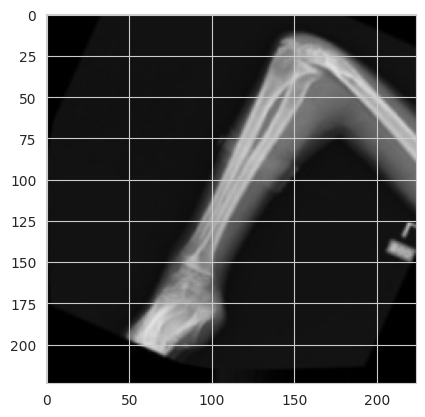

(20, 224, 224, 3)


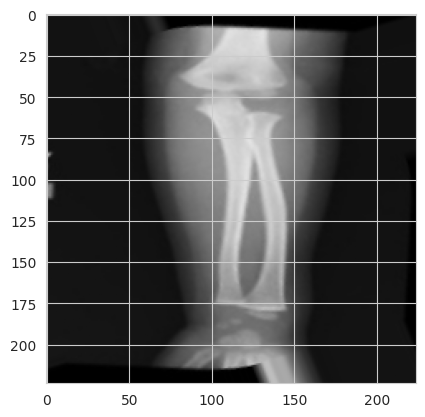

(20, 224, 224, 3)


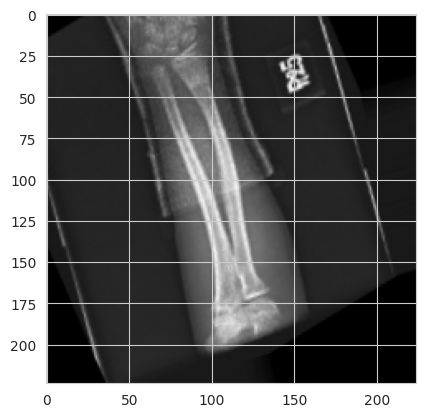

In [13]:
for _ in range(3):
    img, label = next (train_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()

(20, 224, 224, 3)


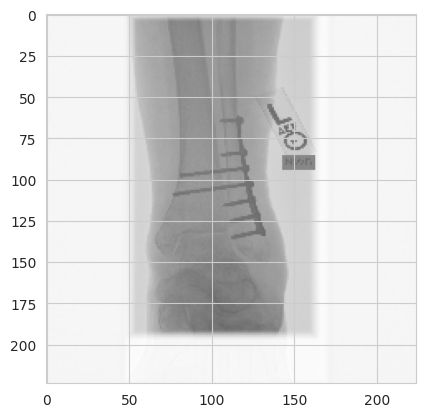

(20, 224, 224, 3)


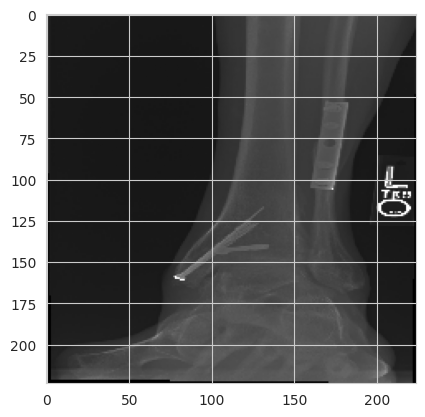

(20, 224, 224, 3)


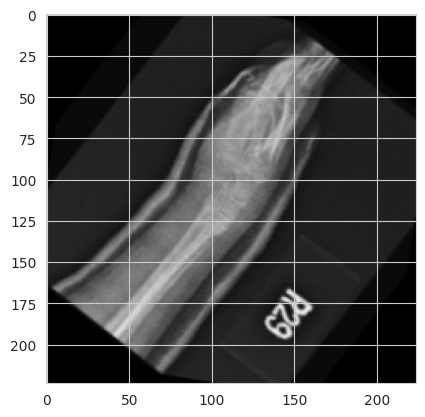

(20, 224, 224, 3)


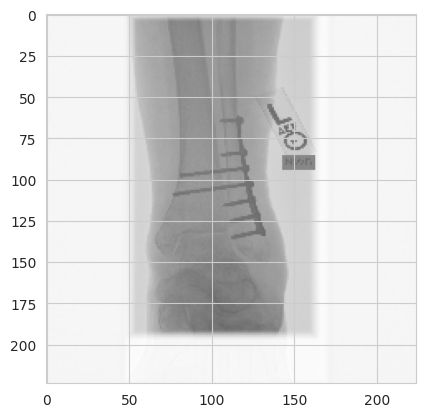

(20, 224, 224, 3)


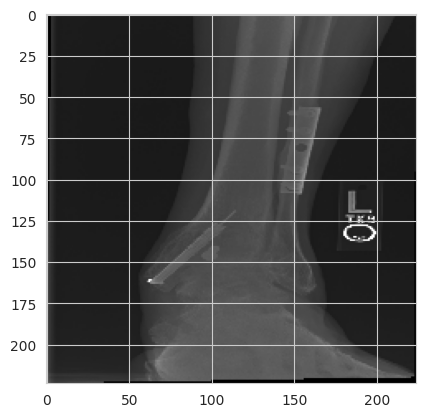

(20, 224, 224, 3)


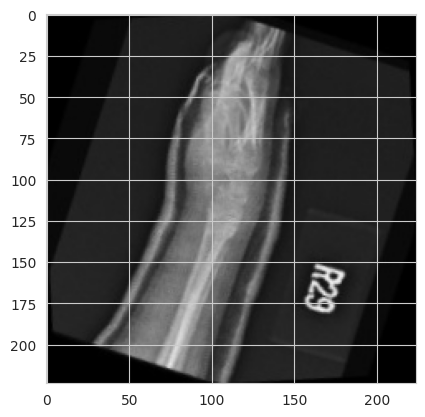

In [14]:
for _ in range(3):
    img, label = next(validation_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()
for _ in range(3):
    img, label = next(test_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()

In [15]:
joblib.dump(value=train_set.class_indices,
            filename=f"{file_path}/class_indices.pkl")

['/workspaces/XrayFractureClass/outputs/class_indices.pkl']

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

In [17]:
def create_tf_model():
    model = Sequential()

    model.add(Conv2D(filters=32, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))

    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    return model

In [18]:
create_tf_model().summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779737180.403203    6385 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,594,369 (21.34 MB)

 Trainable params: 5,594,369 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [20]:
model = create_tf_model()
model.fit(train_set,
          epochs=25,
          steps_per_epoch=len(train_set.classes) // batch_size,
          validation_data=validation_set,
          callbacks=[early_stop],
          verbose=1
          )

Epoch 1/25


I0000 00:00:1779737181.729222    6385 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.5902 - loss: 0.6691

/usr/local/python/3.12.1/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


462/462 ━━━━━━━━━━━━━━━━━━━━ 299s 640ms/step - accuracy: 0.6395 - loss: 0.6341 - val_accuracy: 0.7407 - val_loss: 0.5606
Epoch 2/25
  1/462 ━━━━━━━━━━━━━━━━━━━━ 3:35 467ms/step - accuracy: 0.8000 - loss: 0.5525

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


462/462 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8000 - loss: 0.5525 - val_accuracy: 0.7346 - val_loss: 0.5554
Epoch 3/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 289s 625ms/step - accuracy: 0.7249 - loss: 0.5459 - val_accuracy: 0.8372 - val_loss: 0.4299
Epoch 4/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6500 - loss: 0.5562 - val_accuracy: 0.8335 - val_loss: 0.4256
Epoch 5/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 284s 615ms/step - accuracy: 0.7800 - loss: 0.4755 - val_accuracy: 0.8239 - val_loss: 0.3801
Epoch 6/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6000 - loss: 0.6592 - val_accuracy: 0.8154 - val_loss: 0.3816
Epoch 7/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 285s 617ms/step - accuracy: 0.8083 - loss: 0.4195 - val_accuracy: 0.8456 - val_loss: 0.3817
Epoch 8/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.6500 - loss: 0.5208 - val_accuracy: 0.8456 - val_loss: 0.3910


In [22]:
model.save(f'{file_path}/fracture_detection_model_v1.keras')
print ('The model has been saved')

The model has been saved


In [23]:
history = pd.DataFrame(model.history.history)
history.head()

,accuracy,loss,val_accuracy,val_loss
0,0.639497,0.634139,0.740651,0.560625
1,0.800000,0.552456,0.734620,0.555378
2,0.724908,0.545949,0.837153,0.429870
3,0.650000,0.556205,0.833534,0.425601
4,0.779970,0.475493,0.823884,0.380077


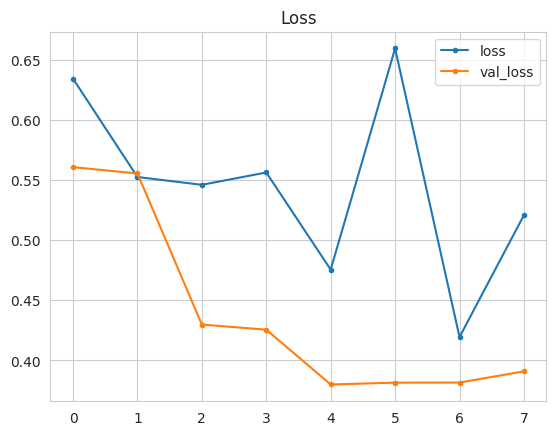

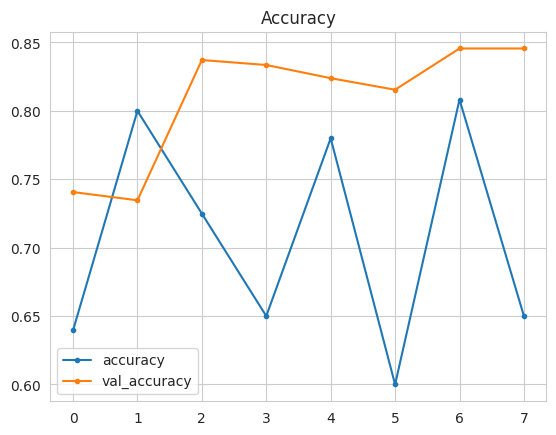

In [24]:
sns.set_style("whitegrid")
history[['loss','val_loss']].plot(style='.-')
plt.title("Loss")
plt.show()

print("\n")
history[['accuracy','val_accuracy']].plot(style='.-')
plt.title("Accuracy")
plt.show()

In [25]:
loss, accuracy = model.evaluate(test_set)
print (f'Test Loss = :{loss:.4f}')
print (f'Test Accuracy = :{accuracy:.4f}')

26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 355ms/step - accuracy: 0.8241 - loss: 0.4215
Test Loss = :0.4215
Test Accuracy = :0.8241


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

def confusion_matrix_and_report(data_set, pipeline, label_map):
    data_set.reset()

    prediction = pipeline.predict(data_set)
    prediction = np.argmax(prediction, axis=1)

y = np.argmax(y, axis=1)

    # Compute confusion matrix
cm = confusion_matrix(y_true=y, y_pred=prediction)

print('---  Confusion Matrix  ---')
print(pd.DataFrame(
        cm,
columns=["Actual " + sub for sub in label_map],
index=["Predicted " + sub for sub in label_map])) print("\n")

print('---  Classification Report  ---')
print(classification_report(y, prediction, target_names=label_map), "\n")

    # 🔹 Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_map,
        yticklabels=label_map
    )

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
def clf_performance(data_set, pipeline, label_map):
  """
  Print classification performance
  """
  print("#### Train Set #### \n")
  confusion_matrix_and_report(data_set, pipeline, label_map)

  print("#### Validation Set #### \n")
  confusion_matrix_and_report(data_set, pipeline, label_map)

  print("#### Test Set ####\n")
  confusion_matrix_and_report(data_set, pipeline, label_map)
clf_performance(X_train, y_train,
                X_test,y_test,
                X_val, y_val,
                model,
                label_map= class_names
                )

NameError: name 'X_train' is not defined